<a href="https://colab.research.google.com/github/RameshwarSanap/generative-ai-projects/blob/main/RAM_SANAP_Practical3GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical No. 03: Autoencoder and Variational Autoencoder for Image Reconstruction and Generation

**Name:** Rameshwar Sanap
**PRN:** 202401110021
**Batch:** AIML-A2
**Department:** CSE-AIML  


---

## Aim

To build an **Autoencoder** and a **Variational Autoencoder (VAE)** using the MNIST dataset for image reconstruction and generation, and compare the performance of both models based on the quality of reconstructed and generated images.




### What is an Autoencoder?

An **Autoencoder** is a type of neural network that learns to reproduce its input at the output.

It consists of two main parts:

1. **Encoder** – Compresses the input image into a smaller representation called the latent representation.
2. **Decoder** – Takes the latent representation and reconstructs the original image.

The basic flow is:

**Input Image → Encoder → Latent Representation → Decoder → Reconstructed Image**

The Autoencoder is trained by minimizing the difference between the original image and the reconstructed image.



### What is a Variational Autoencoder?

A **Variational Autoencoder (VAE)** is an advanced form of Autoencoder that learns a probability distribution in the latent space instead of learning only a fixed latent representation.

The VAE encoder produces two values:

- **Mean (μ)**
- **Log variance (log σ²)**

A latent vector is then sampled from this distribution using the **reparameterization trick**.

The basic flow is:

**Input Image → Encoder → Mean & Variance → Sampling → Latent Vector → Decoder → Reconstructed Image**

The VAE uses two main losses:

1. **Reconstruction Loss** – Measures how similar the reconstructed image is to the original image.
2. **KL Divergence Loss** – Regularizes the latent space so that it follows a standard normal distribution.

The total VAE loss is:

**Total Loss = Reconstruction Loss + KL Divergence Loss**

Because of its structured latent space, a VAE can generate new images by randomly sampling points from the latent space.

## Dataset Description

### MNIST Dataset

The **MNIST dataset** is a standard dataset containing handwritten digits from **0 to 9**.

The dataset contains:

- **60,000 training images**
- **10,000 testing images**
- Image size: **28 × 28 pixels**
- Image type: **Grayscale**
- Number of classes: **10 (0–9)**

For this practical, the images are used as both the input and target because the objective is image reconstruction.

The pixel values are originally in the range **0 to 255**. They will be normalized to the range **0 to 1** before training the models.

In [1]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Step 1: Load the MNIST Dataset

The MNIST dataset is available directly through Keras.

We load the training and testing images along with their labels.

Since this practical focuses on reconstruction rather than classification, the labels are not required for training the Autoencoder and VAE.

In [2]:
# Load MNIST dataset

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
Training labels: (60000,)
Testing labels: (10000,)


## Step 2: Visualize Sample Images

Before preprocessing the data, we display some sample images from the MNIST dataset.

This helps us understand the type of images that will be given to the Autoencoder and VAE.

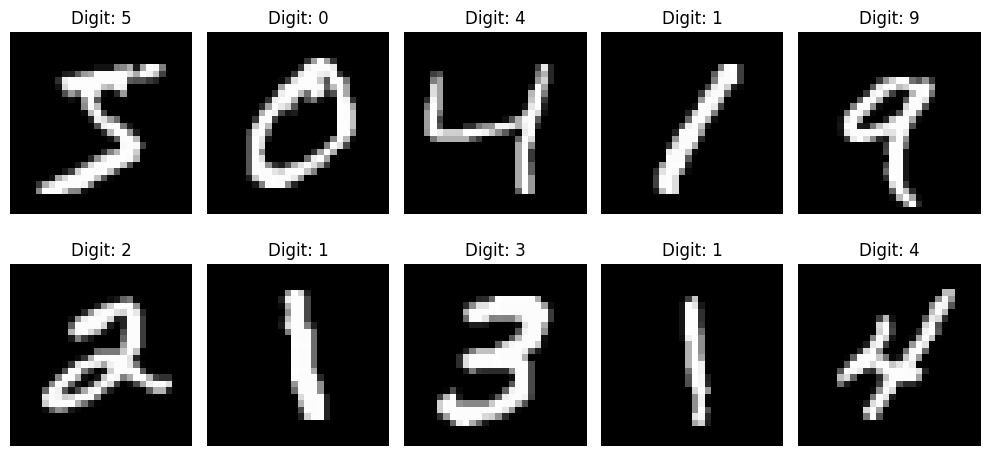

In [3]:
# Display sample MNIST images

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 3: Preprocess the Dataset

The pixel values in the MNIST images range from **0 to 255**.

Neural networks perform better when the input values are scaled to a smaller range.

Therefore, the pixel values are normalized using:

**Pixel Value = Pixel Value / 255**

After normalization, the pixel values lie between **0 and 1**.

We also add a channel dimension because convolutional neural networks expect image data in the format:

**Height × Width × Channels**

Therefore, the image shape changes from:

**28 × 28 → 28 × 28 × 1**

In [4]:
# Normalize pixel values

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Part A: Building the Autoencoder

### Step 4: Autoencoder Architecture

The Autoencoder consists of two major components:

#### **Encoder**

The encoder compresses the input image into a smaller latent representation.

#### **Decoder**

The decoder reconstructs the original image from the latent representation.

The architecture used in this practical is:

**Input Image (28 × 28 × 1)**  
↓  
**Convolutional Layer**  
↓  
**Convolutional Layer**  
↓  
**Flatten Layer**  
↓  
**Latent Representation (128 dimensions)**  
↓  
**Decoder**  
↓  
**Reconstructed Image (28 × 28 × 1)**

The Autoencoder will use **Mean Squared Error (MSE)** as the reconstruction loss.

In [5]:
# Define latent dimension

latent_dim = 128

# Encoder input

encoder_inputs = keras.Input(
    shape=(28, 28, 1),
    name="encoder_input"
)

# Encoder layers

x = layers.Conv2D(
    32,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu"
)(encoder_inputs)

x = layers.Conv2D(
    64,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Flatten()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

latent = layers.Dense(
    latent_dim,
    name="latent_vector"
)(x)

# Create encoder model

encoder = keras.Model(
    encoder_inputs,
    latent,
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 128)            │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 436,864 (1.67 MB)

 Trainable params: 436,864 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Build the Autoencoder Decoder

The decoder takes the latent representation generated by the encoder and reconstructs the original image.

The decoder performs the reverse operation of the encoder.

The latent vector is first converted into a suitable shape and then upsampled using transposed convolutional layers.

The final layer uses the **sigmoid activation function** because the image pixel values are normalized between 0 and 1.

In [6]:
# Decoder input

latent_inputs = keras.Input(
    shape=(latent_dim,),
    name="latent_input"
)

# Convert latent vector to feature maps

x = layers.Dense(
    7 * 7 * 64,
    activation="relu"
)(latent_inputs)

x = layers.Reshape(
    (7, 7, 64)
)(x)

# Upsampling layers

x = layers.Conv2DTranspose(
    64,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

# Output layer

decoder_outputs = layers.Conv2DTranspose(
    1,
    kernel_size=3,
    padding="same",
    activation="sigmoid"
)(x)

# Create decoder model

decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_input (InputLayer)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,225 (1.76 MB)

 Trainable params: 460,225 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Combine Encoder and Decoder

The encoder and decoder are now combined to form the complete Autoencoder.

The complete data flow is:

**Input Image → Encoder → Latent Representation → Decoder → Reconstructed Image**

The Autoencoder tries to make the reconstructed image as similar as possible to the original input image.

In [7]:
# Create complete Autoencoder

autoencoder_inputs = keras.Input(
    shape=(28, 28, 1),
    name="autoencoder_input"
)

encoded = encoder(autoencoder_inputs)

decoded = decoder(encoded)

autoencoder = keras.Model(
    autoencoder_inputs,
    decoded,
    name="autoencoder"
)

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 128)            │       436,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       460,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,089 (3.42 MB)

 Trainable params: 897,089 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Compile the Autoencoder

The Autoencoder is compiled using the **Adam optimizer**.

The reconstruction loss used is **Mean Squared Error (MSE)**.

MSE measures the average squared difference between the original image and the reconstructed image.

A lower reconstruction loss indicates that the reconstructed image is closer to the original image.

In [8]:
# Compile Autoencoder

autoencoder.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mse"
)

print("Autoencoder compiled successfully.")

Autoencoder compiled successfully.


## Step 8: Train the Autoencoder

The Autoencoder receives the original images as both:

- Input
- Target output

Therefore:

**Input = x_train**

**Target = x_train**

The model learns how to reconstruct the input image.

The model is trained for 10 epochs with a batch size of 128.

In [9]:
# Train Autoencoder

history_ae = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0359 - val_loss: 0.0085
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0062 - val_loss: 0.0046
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0042 - val_loss: 0.0038
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0034 - val_loss: 0.0030
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0019 - val_loss: 0.0019


## Step 9: Visualize Autoencoder Training Loss

The training and validation loss are plotted to observe how the Autoencoder learns during training.

A decreasing loss indicates that the model is improving its reconstruction ability.

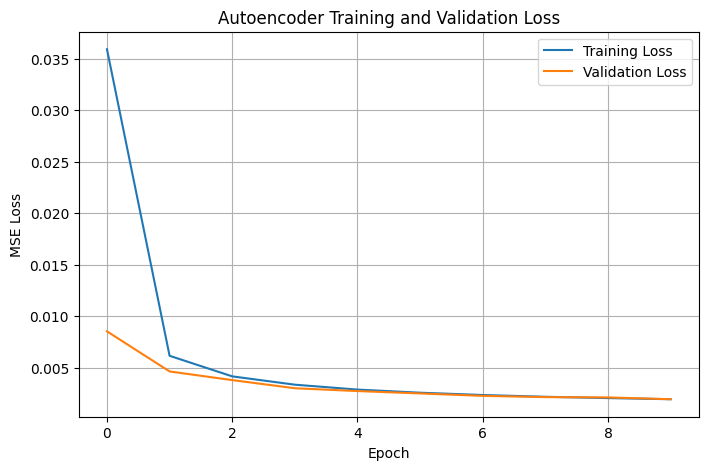

In [10]:
# Plot Autoencoder loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_ae.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_ae.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

## Step 10: Reconstruct Images Using Autoencoder

The trained Autoencoder is now used to reconstruct images from the test dataset.

The reconstructed images will be compared with their corresponding original images.

In [11]:
# Reconstruct test images

ae_reconstructed = autoencoder.predict(
    x_test[:10],
    verbose=0
)

print("Reconstructed images shape:", ae_reconstructed.shape)

Reconstructed images shape: (10, 28, 28, 1)


## Step 11: Compare Original and Reconstructed Images

The first row contains the original MNIST images.

The second row contains the images reconstructed by the Autoencoder.

The reconstruction quality can be visually analyzed by comparing the two rows.

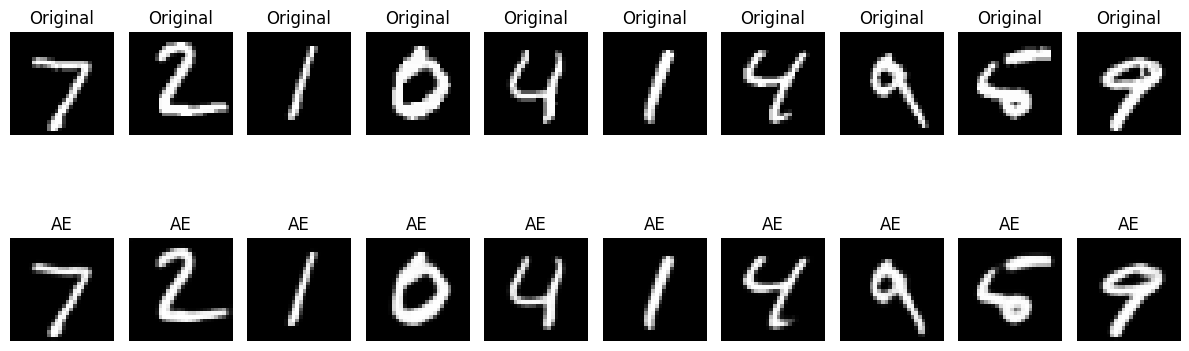

In [12]:
# Display original and reconstructed images

plt.figure(figsize=(12, 5))

for i in range(10):

    # Original image
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    plt.subplot(2, 10, i + 11)
    plt.imshow(ae_reconstructed[i].squeeze(), cmap="gray")
    plt.title("AE")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Part B: Building the Variational Autoencoder (VAE)

## Step 12: VAE Architecture

A Variational Autoencoder is different from a traditional Autoencoder because the encoder produces a probability distribution instead of a single fixed latent vector.

The encoder produces:

- **Mean (μ)**
- **Log Variance (log σ²)**

A latent vector **z** is then sampled from this distribution.

The architecture is:

**Input Image**  
↓  
**Encoder**  
↓  
**Mean (μ) + Log Variance (log σ²)**  
↓  
**Sampling**  
↓  
**Latent Vector z**  
↓  
**Decoder**  
↓  
**Reconstructed Image**

For this practical, the latent dimension is set to **2** so that the learned latent space can also be visualized.

In [13]:
# Set VAE latent dimension

latent_dim = 2

print("VAE latent dimension:", latent_dim)

VAE latent dimension: 2


## Step 13: Build the VAE Encoder

The VAE encoder extracts features from the input image and produces two outputs:

1. Mean (μ)
2. Log Variance (log σ²)

These values define the probability distribution from which the latent vector is sampled.

In [14]:
# VAE Encoder input

vae_encoder_inputs = keras.Input(
    shape=(28, 28, 1),
    name="vae_encoder_input"
)

# Encoder layers

x = layers.Conv2D(
    32,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu"
)(vae_encoder_inputs)

x = layers.Conv2D(
    64,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Flatten()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

# Mean and log variance

z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)

## Step 14: Reparameterization Trick

The VAE needs to sample a latent vector from the learned probability distribution.

Direct random sampling would make backpropagation difficult.

Therefore, the **reparameterization trick** is used.

The equation is:

**z = μ + σ × ε**

where:

- **μ** = mean
- **σ** = standard deviation
- **ε** = random noise sampled from a standard normal distribution

The standard deviation is obtained using:

**σ = exp(0.5 × log variance)**

This allows the VAE to perform random sampling while still allowing gradients to flow during training.

In [15]:
# Reparameterization / Sampling layer

class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]

        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(
            shape=(batch, dim)
        )

        return (
            z_mean
            + tf.exp(0.5 * z_log_var)
            * epsilon
        )

## Step 15: Create the VAE Encoder Model

The Sampling layer is connected to the mean and log variance.

The encoder now produces:

- Mean
- Log variance
- Sampled latent vector

In [16]:
# Sample latent vector

z = Sampling()([z_mean, z_log_var])

# Create VAE encoder

vae_encoder = keras.Model(
    vae_encoder_inputs,
    [z_mean, z_log_var, z],
    name="vae_encoder"
)

vae_encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │        320 │ vae_encoder_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    401,536 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 16: Build the VAE Decoder

The VAE decoder receives the sampled latent vector and reconstructs the original image.

Since the latent dimension is 2, the decoder first expands this 2-dimensional vector into a larger feature representation and then uses transposed convolutional layers to generate a 28 × 28 image.

In [17]:
# VAE Decoder input

latent_inputs = keras.Input(
    shape=(latent_dim,),
    name="z_sampling"
)

# Expand latent vector

x = layers.Dense(
    7 * 7 * 64,
    activation="relu"
)(latent_inputs)

x = layers.Reshape(
    (7, 7, 64)
)(x)

# Upsampling

x = layers.Conv2DTranspose(
    64,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32,
    kernel_size=3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

# Output image

vae_decoder_outputs = layers.Conv2DTranspose(
    1,
    kernel_size=3,
    padding="same",
    activation="sigmoid"
)(x)

# Create decoder model

vae_decoder = keras.Model(
    latent_inputs,
    vae_decoder_outputs,
    name="vae_decoder"
)

vae_decoder.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 17: Define the VAE Loss

The VAE uses two losses.

### 1. Reconstruction Loss

This measures the difference between the original image and reconstructed image.

### 2. KL Divergence Loss

KL divergence forces the learned latent distribution to remain close to a standard normal distribution.

The total VAE loss is:

**Total Loss = Reconstruction Loss + KL Divergence Loss**

This combination allows the VAE to perform both image reconstruction and image generation.

In [18]:
# Define the VAE model

class VAE(keras.Model):

    def __init__(self, encoder, decoder, **kwargs):

        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):

        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            # Reconstruction loss

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL divergence loss

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss

            total_loss = (
                reconstruction_loss
                + kl_loss
            )

        # Calculate gradients

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # Update model weights

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        # Update metrics

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)

        reconstruction = self.decoder(z)

        return reconstruction

## Step 18: Compile the VAE

The VAE uses the **Adam optimizer**.

Since the VAE has a custom training step, the reconstruction loss and KL divergence loss are calculated manually inside the `train_step()` function.

The total loss is calculated as:

**Total Loss = Reconstruction Loss + KL Divergence Loss**

In [19]:
# Create VAE

vae = VAE(
    vae_encoder,
    vae_decoder
)

vae.compile(
    optimizer=keras.optimizers.Adam()
)

print("VAE compiled successfully.")


VAE compiled successfully.


## Step 19: Train the VAE

The VAE is trained using the MNIST training images.

During training, the VAE learns:

- Important image features
- A structured latent distribution
- How to reconstruct the input image
- How to organize the latent space for image generation

The VAE calculates three important metrics during training:

- Total Loss
- Reconstruction Loss
- KL Divergence Loss

The model is trained for **10 epochs** with a **batch size of 128**.

In [20]:
history_vae = vae.fit(
    x_train,
    epochs=10,
    batch_size=128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - kl_loss: 3.5590 - loss: 206.2702 - reconstruction_loss: 202.7112
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 4.9295 - loss: 166.5817 - reconstruction_loss: 161.6522
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.4695 - loss: 158.9939 - reconstruction_loss: 153.5245
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.7146 - loss: 155.6521 - reconstruction_loss: 149.9375
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.8453 - loss: 153.7078 - reconstruction_loss: 147.8626
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.9681 - loss: 152.1836 - reconstruction_loss: 146.2154
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 6.0561 - loss: 150.9572 - reconstruction_loss: 144.9010
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 6.1504 - loss: 150.0578 - reconstruction_loss: 143.9074
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms

## Step 20: Plot VAE Training Loss

The VAE has three important metrics:

- Total Loss
- Reconstruction Loss
- KL Divergence Loss

These losses help us understand how the VAE is learning.

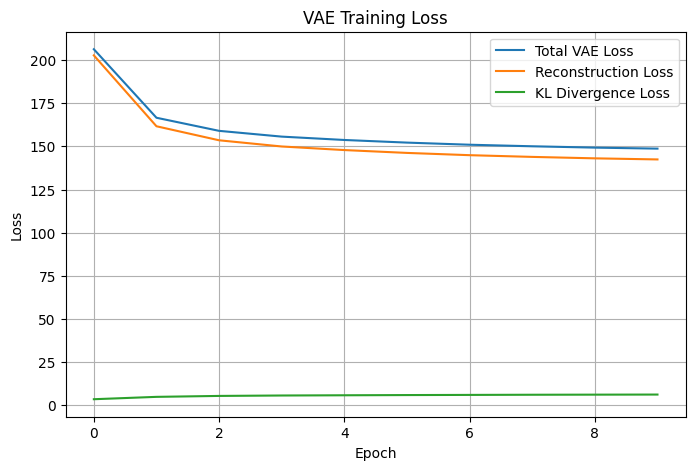

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_vae.history["loss"],
    label="Total VAE Loss"
)

plt.plot(
    history_vae.history["reconstruction_loss"],
    label="Reconstruction Loss"
)

plt.plot(
    history_vae.history["kl_loss"],
    label="KL Divergence Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.grid(True)

plt.show()

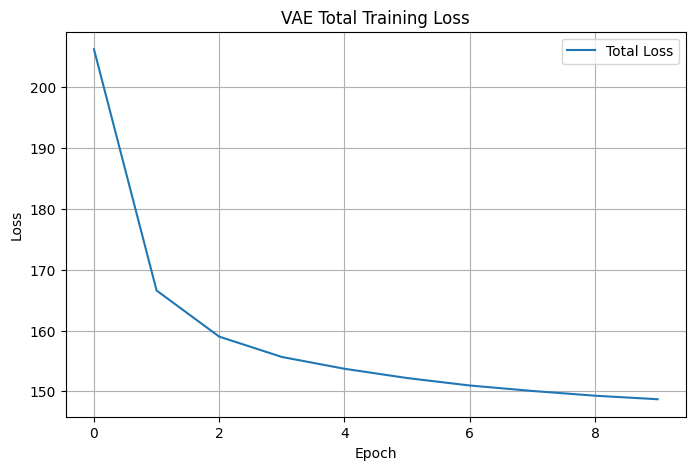

In [22]:
# Plot VAE total loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_vae.history["loss"],
    label="Total Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Total Training Loss")
plt.legend()
plt.grid(True)

plt.show()

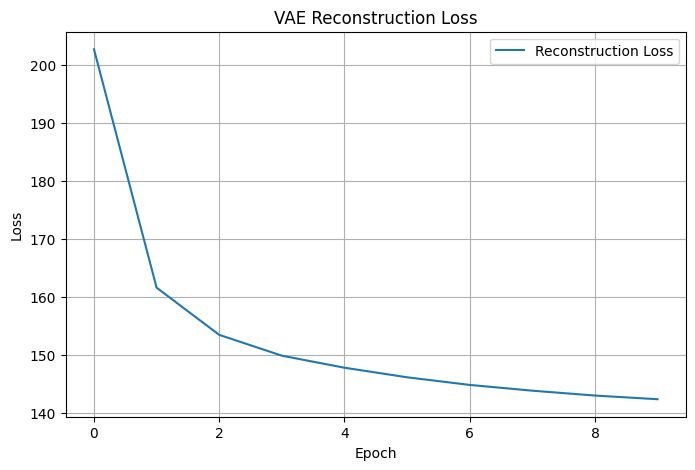

In [23]:
# Plot reconstruction loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_vae.history["reconstruction_loss"],
    label="Reconstruction Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Reconstruction Loss")
plt.legend()
plt.grid(True)

plt.show()

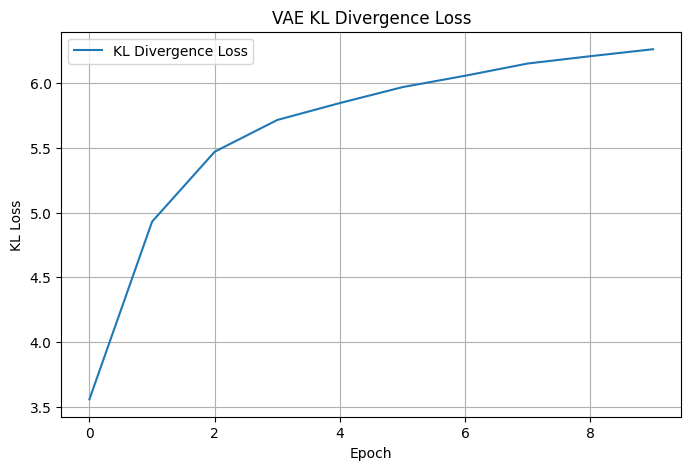

In [24]:
# Plot KL divergence loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_vae.history["kl_loss"],
    label="KL Divergence Loss"
)

plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("VAE KL Divergence Loss")
plt.legend()
plt.grid(True)

plt.show()

## Step 21: Reconstruct Images Using VAE

The trained VAE is now used to reconstruct images from the MNIST test dataset.

The reconstructed images will be compared with the original images to evaluate the reconstruction quality.

In [25]:
# Reconstruct test images using VAE

vae_reconstructed = vae.predict(
    x_test[:10],
    verbose=0
)

print(
    "VAE reconstructed shape:",
    vae_reconstructed.shape
)

VAE reconstructed shape: (10, 28, 28, 1)


## Step 22: Compare Original and VAE Reconstructed Images

The first row contains the original MNIST images.

The second row contains the images reconstructed by the VAE.

The visual quality of the reconstructed images can be compared with the original images.

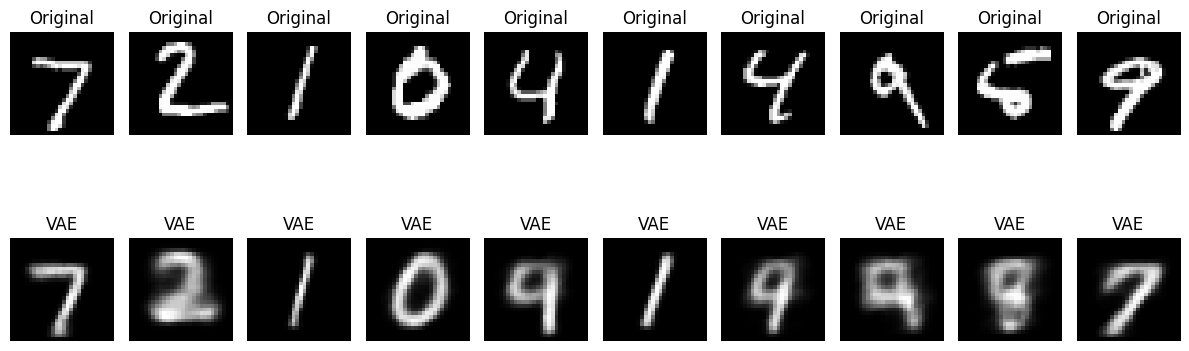

In [26]:
# Display original and VAE reconstructed images

plt.figure(figsize=(12, 5))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    # VAE reconstruction
    plt.subplot(2, 10, i + 11)

    plt.imshow(
        vae_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.title("VAE")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Part C: Image Generation Using VAE

## Step 23: Generate New Images

One of the major advantages of a VAE is that it can generate new images.

The VAE learns a structured latent space that is approximately distributed like a standard normal distribution.

Therefore, random points can be sampled from the latent space and passed to the decoder.

The decoder then converts these random latent vectors into new handwritten digit images.

The generated images are not direct copies of the training images. They are new samples created by the decoder from the learned latent representation.

In [27]:
# Generate new images using random latent vectors

num_generated = 20

random_latent_vectors = np.random.normal(
    size=(num_generated, latent_dim)
)

generated_images = vae_decoder.predict(
    random_latent_vectors,
    verbose=0
)

print(
    "Generated images shape:",
    generated_images.shape
)

Generated images shape: (20, 28, 28, 1)


## Step 24: Display Generated Images

The generated images are displayed below.

These images are created by sampling random points from the VAE latent space and passing them through the trained decoder.

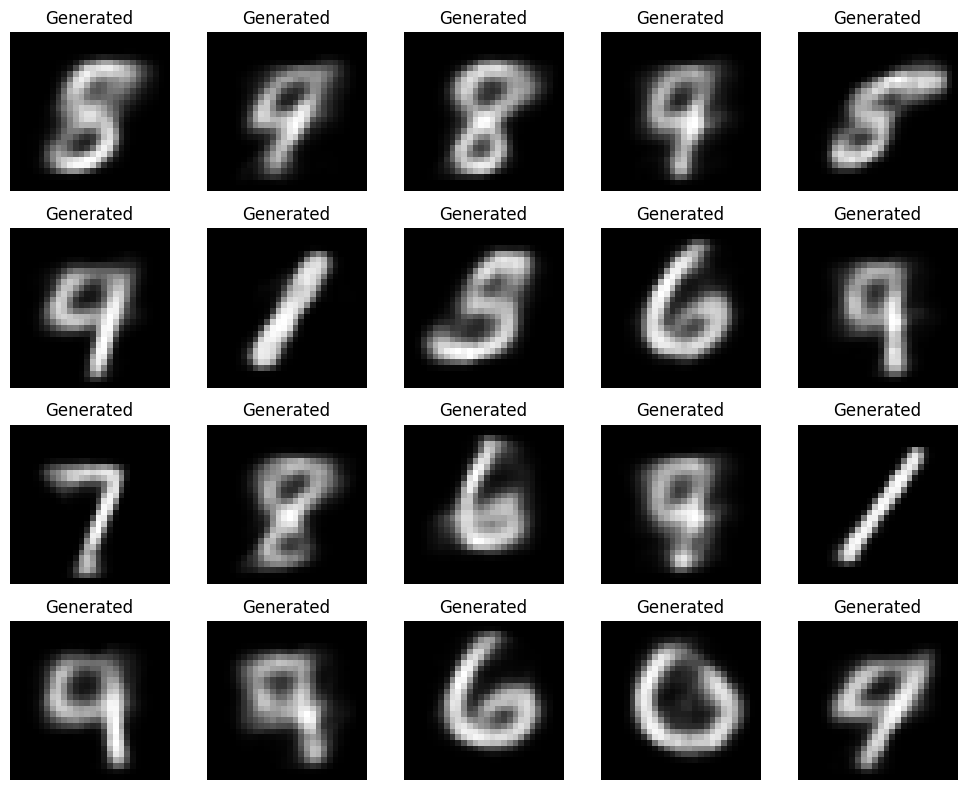

In [28]:
# Display generated images

plt.figure(figsize=(10, 8))

for i in range(num_generated):

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Part D: VAE Latent Space Visualization

## Step 25: Visualize the Latent Space

Since the VAE uses a **2-dimensional latent space**, we can visualize the learned representation.

Each MNIST image is converted into a point with two coordinates:

- Latent Dimension 1
- Latent Dimension 2

Images belonging to similar digits are expected to appear closer together in the latent space.

This demonstrates that the VAE learns a meaningful and structured representation of the input images.

In [29]:
# Obtain latent representations

z_mean, z_log_var, z = vae_encoder.predict(
    x_test,
    verbose=0
)

print("Latent representation shape:", z_mean.shape)

Latent representation shape: (10000, 2)


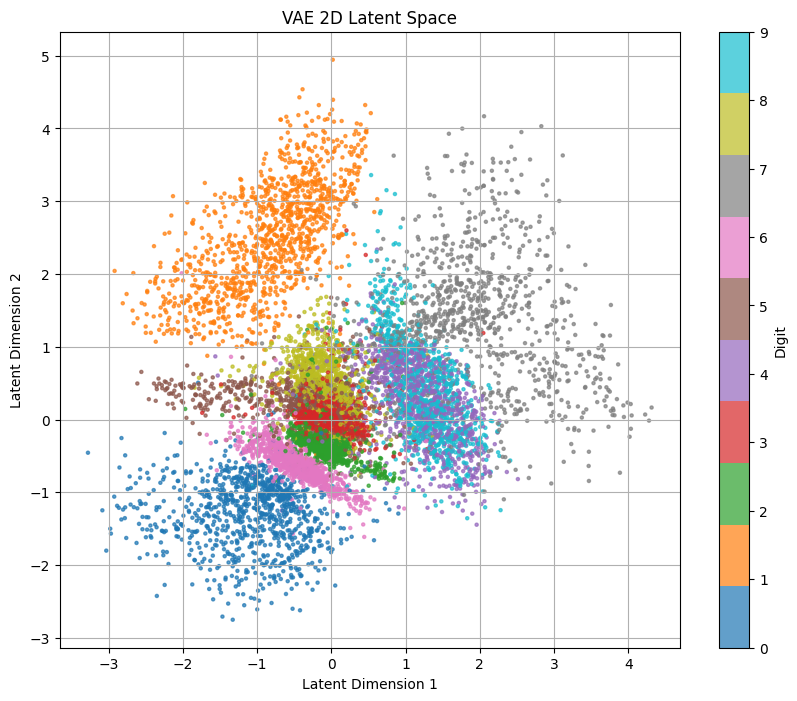

In [30]:
# Visualize VAE latent space

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_mean[:, 0],
    z_mean[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.7
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.title("VAE 2D Latent Space")

plt.grid(True)

plt.show()

# Part E: Performance Comparison

## Step 26: Compare Reconstruction Quality

The reconstruction performance of both models is evaluated using **Mean Squared Error (MSE)**.

MSE measures the average squared difference between the original image and reconstructed image.

A lower MSE means that the reconstructed image is numerically closer to the original image.

However, reconstruction error alone is not sufficient for comparing an Autoencoder and VAE because the VAE also optimizes the latent space for generation.

In [31]:
# Calculate Autoencoder reconstruction MSE

ae_predictions = autoencoder.predict(
    x_test[:1000],
    verbose=0
)

ae_mse = np.mean(
    np.square(
        x_test[:1000] - ae_predictions
    )
)

print(
    "Autoencoder Reconstruction MSE:",
    ae_mse
)

Autoencoder Reconstruction MSE: 0.0019229847


In [32]:
# Calculate VAE reconstruction MSE

vae_predictions = vae.predict(
    x_test[:1000],
    verbose=0
)

vae_mse = np.mean(
    np.square(
        x_test[:1000] - vae_predictions
    )
)

print(
    "VAE Reconstruction MSE:",
    vae_mse
)

VAE Reconstruction MSE: 0.04091561


## Step 27: Compare Reconstruction Errors

The calculated MSE values of the Autoencoder and VAE are compared.

A lower MSE indicates lower pixel-level reconstruction error.

The Autoencoder may achieve a lower reconstruction error because its main objective is direct reconstruction. The VAE has an additional KL divergence objective that encourages a smooth and structured latent space.

In [33]:
# Display reconstruction errors

print("==============================================")
print("       RECONSTRUCTION ERROR COMPARISON")
print("==============================================")

print(f"Autoencoder MSE : {ae_mse:.6f}")
print(f"VAE MSE         : {vae_mse:.6f}")

       RECONSTRUCTION ERROR COMPARISON
Autoencoder MSE : 0.001923
VAE MSE         : 0.040916


## Step 28: Plot Reconstruction Error Comparison

The reconstruction errors are visualized using a bar graph.

This provides an easy visual comparison between the Autoencoder and VAE.

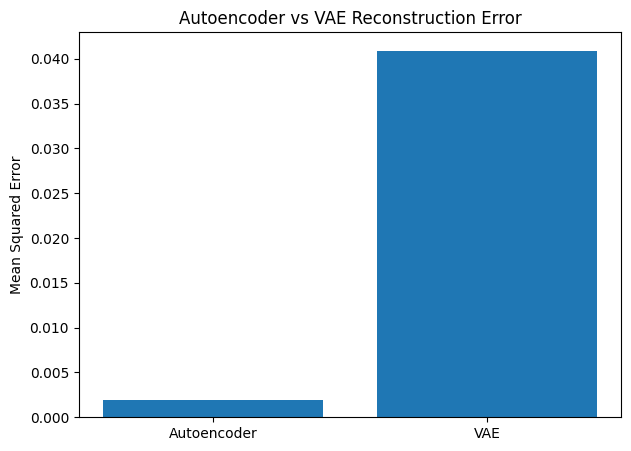

In [34]:
# Plot MSE comparison

models = ["Autoencoder", "VAE"]
mse_values = [ae_mse, vae_mse]

plt.figure(figsize=(7, 5))

plt.bar(
    models,
    mse_values
)

plt.ylabel("Mean Squared Error")
plt.title("Autoencoder vs VAE Reconstruction Error")

plt.show()

## Step 29: Visual Comparison of Reconstruction

The following visualization compares the same images reconstructed by both models.

The rows represent:

1. Original Images
2. Autoencoder Reconstructions
3. VAE Reconstructions

This visual comparison helps us analyze differences that may not be completely represented by MSE alone.

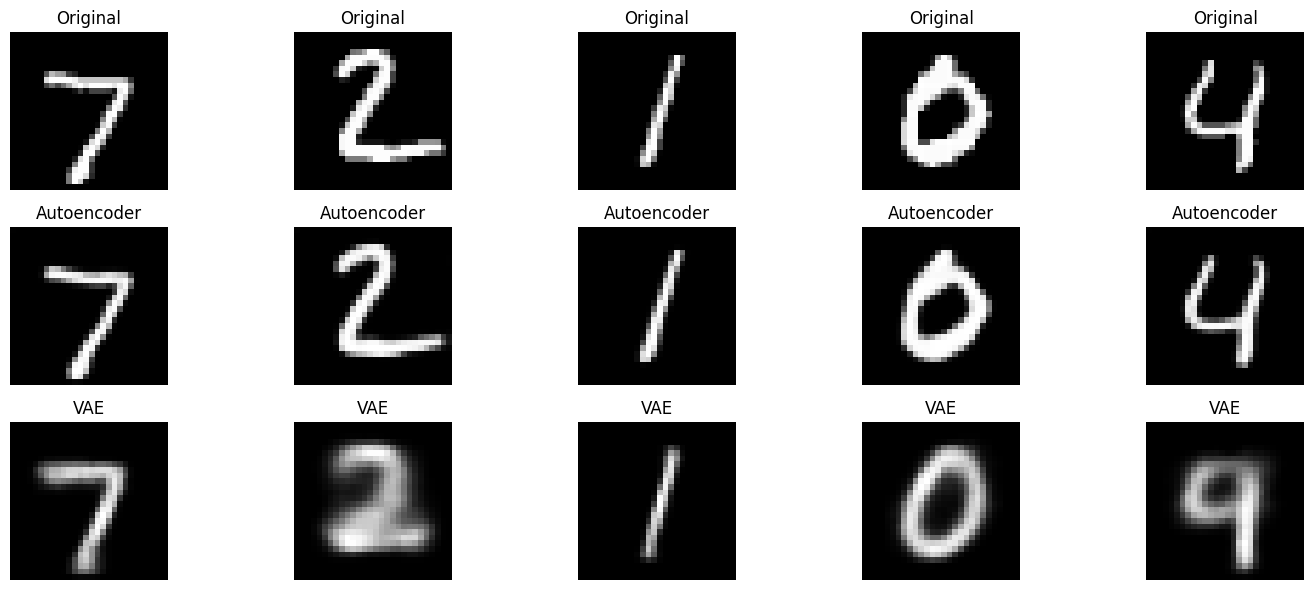

In [35]:
# Compare Original, Autoencoder and VAE

plt.figure(figsize=(15, 6))

for i in range(5):

    # Original
    plt.subplot(3, 5, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    # Autoencoder
    plt.subplot(3, 5, i + 6)

    plt.imshow(
        ae_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.title("Autoencoder")
    plt.axis("off")

    # VAE
    plt.subplot(3, 5, i + 11)

    plt.imshow(
        vae_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.title("VAE")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Step 30: Autoencoder vs VAE Comparison

| Parameter | Autoencoder | Variational Autoencoder |
|-----------|-------------|-------------------------|
| Main purpose | Reconstruction and feature learning | Reconstruction and generation |
| Encoder output | Fixed latent vector | Mean and log variance |
| Latent space | Deterministic | Probabilistic |
| Reconstruction | Generally sharper | Generally smoother |
| Image generation | Limited | Strong generative capability |
| Latent space regularization | No | Yes |
| Loss function | Reconstruction loss | Reconstruction loss + KL divergence |
| Random sampling | Not naturally supported | Naturally supported |
| Application | Compression, reconstruction, feature extraction | Generative modeling, image generation |

### Overall Observation

The Autoencoder is primarily optimized to reconstruct the input image, so it can provide good reconstruction quality.

The VAE sacrifices some reconstruction accuracy in exchange for learning a smooth and structured latent space. This makes it suitable for generating new images.

Therefore, the two models are useful for different purposes:

- **Autoencoder → Better suited for reconstruction and feature learning**
- **VAE → Better suited for generative modeling and new image generation**

# Results

### Autoencoder Results

The Autoencoder successfully learned a compressed latent representation of the MNIST images and reconstructed the handwritten digits.

The reconstructed images were visually similar to the original images.

### VAE Results

The Variational Autoencoder successfully reconstructed the MNIST images and learned a structured 2-dimensional latent space.

The VAE was also able to generate new handwritten digit-like images by sampling random points from the latent space.

### Performance Comparison

The Autoencoder generally provides strong reconstruction performance because it directly minimizes reconstruction error.

The VAE may produce slightly smoother or blurrier reconstructions because it also optimizes KL divergence.

However, the VAE provides an important additional capability: **generation of new images from random latent vectors**.

# Conclusion

In this practical, an **Autoencoder** and a **Variational Autoencoder (VAE)** were successfully implemented using the MNIST handwritten digit dataset.

The Autoencoder learned to compress the input images into a latent representation and reconstruct them successfully. The VAE also reconstructed the images while learning a probabilistic and structured latent space.

The reconstruction performance of both models was compared using Mean Squared Error and visual inspection of reconstructed images.

The major difference observed was in image generation. The Autoencoder is mainly designed for reconstruction and does not naturally provide a structured latent space for random image generation. In contrast, the VAE learns a continuous probability distribution in the latent space, allowing new images to be generated by sampling random latent vectors.

Thus, the Autoencoder is useful for **image reconstruction, compression, and feature extraction**, while the VAE is particularly useful for **generative modeling and creating new images**.